<a href="https://colab.research.google.com/github/Fegel12/Unab/blob/main/1_6_EDA_en_datos_num%C3%A9ricos_Fergel1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



<img src="https://d1yjjnpx0p53s8.cloudfront.net/styles/logo-thumbnail/s3/102012/logo_unab.png?itok=hZ5x30O2" width="240" height="240" align="right"/>


<center><h1>Estadística para la Ciencia de Datos</header1></center>
<left><h1>Unidad 1: Análisis exploratorio de datos</header1></left>

# ¿Qué es EDA?

Es el proceso para revisar y depurar los datos, buscando:
- Obtener información
- Generar hipótesis

Este notebook se centra únicamente en relaciones de variables explícitamente numéricas.

In [ ]:
# paquetes necesarios en esta sección
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
file_path='https://raw.githubusercontent.com/JSebasB90/datasets/refs/heads/main/clean_books.csv'

In [ ]:
df = pd.read_csv(file_path)

In [ ]:
df.head()

,name,author,rating,year,genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,2016.0,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2011.0,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,2018.0,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,2017.0,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,2019.0,Childrens


## Data validation

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    351 non-null    object 
 1   author  351 non-null    object 
 2   rating  351 non-null    object 
 3   year    351 non-null    float64
 4   genre   351 non-null    object 
dtypes: float64(1), object(4)
memory usage: 13.8+ KB


## Codificación de tipos numéricos

Observe que la columna rating no esta bien codificada

In [ ]:
df.dtypes

,0
name,object
author,object
rating,object
year,float64
genre,object


Note que la última fila tiene mal digitado símbolo decimal en *rating* y además el año esta en decimal.

In [ ]:
df.tail()

,name,author,rating,year,genre
346,Winter of the World: Book Two of the Century T...,Ken Follett,4.5,2012.0,Fiction
347,Women Food and God: An Unexpected Path to Almo...,Geneen Roth,4.2,2010.0,Non Fiction
348,Wonder,R. J. Palacio,4.8,2013.0,Fiction
349,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,2019.0,Childrens
350,False book,False author,4;9,2024.5,Non Fiction


Los distintos tipos son:
- String: `str`
- Integer: `int`
- Float: `float`
- Dictionary: `dict`
- List: `list`
- Boolean: `bool`

Vamos a hacer una copia de seguridad

In [ ]:
df1 = df.copy()

In [ ]:
# Convertir a numérico
df1['rating'] = pd.to_numeric(df1['rating'], errors='coerce')
df1.dtypes

,0
name,object
author,object
rating,float64
year,float64
genre,object


In [ ]:
df1.isna().sum()

,0
name,0
author,0
rating,1
year,0
genre,0


In [ ]:
df1.tail()

,name,author,rating,year,genre
346,Winter of the World: Book Two of the Century T...,Ken Follett,4.5,2012.0,Fiction
347,Women Food and God: An Unexpected Path to Almo...,Geneen Roth,4.2,2010.0,Non Fiction
348,Wonder,R. J. Palacio,4.8,2013.0,Fiction
349,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,2019.0,Childrens
350,False book,False author,NaN,2024.5,Non Fiction


Al hacerlo de esta forma se perderia en valor, por lo tanto lo correcto es identificar los errores y una forma general de subsanarlo.

In [ ]:
# Reemplazar ';' por '.'
df['rating'] = df['rating'].astype(str).str.replace(';', '.', regex=False)

# Convertir a numérico
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

En el caso del año, vamos a reemplazarlo de forma directa

In [ ]:
# Reemplazar '2024.5' por '2024'
df['year'] = df['year'].astype(str).str.replace('2024.5', '2024', regex=False)

# codificar como entero
df['year'] = df['year'].astype(float).astype(int)

In [ ]:
df.select_dtypes('number').tail()

,rating,year
346,4.5,2012
347,4.2,2010
348,4.8,2013
349,4.9,2019
350,4.9,2024


### Otro ejemplo común

También podemos tener problemas con los signos de puntuación en números.

In [ ]:
data = {
    "index": [0, 1, 2, 3, 4],
    "precio": [
        "20,688,070.00",
        "8,674,985.00",
        "1,591,390.00",
        "11,935,425.00",
        "5,729,004.00"
    ]
}

df2 = pd.DataFrame(data)

In [ ]:
df2.head()

,index,precio
0,0,"20,688,070.00"
1,1,"8,674,985.00"
2,2,"1,591,390.00"
3,3,"11,935,425.00"
4,4,"5,729,004.00"


In [ ]:
df2.dtypes

,0
index,int64
precio,object


Vamos a eliminar las ',' que generan el error

In [ ]:
# Reemplazar ';' por '.'
df2['precio'] = df2['precio'].astype(str).str.replace(',', '', regex=False)

In [ ]:
df2.head()

,index,precio
0,0,20688070.00
1,1,8674985.00
2,2,1591390.00
3,3,11935425.00
4,4,5729004.00


In [ ]:
df2.dtypes

,0
index,int64
precio,object


In [ ]:
df2['precio'] = pd.to_numeric(df2['precio'], errors='coerce')
df2.dtypes

,0
index,int64
precio,float64


In [ ]:
df2

,index,precio
0,0,20688070.0
1,1,8674985.0
2,2,1591390.0
3,3,11935425.0
4,4,5729004.0


In [ ]:
df2.describe()

,index,precio
count,5.000000,5.000000e+00
mean,2.000000,9.723775e+06
std,1.581139,7.216318e+06
min,0.000000,1.591390e+06
25%,1.000000,5.729004e+06
50%,2.000000,8.674985e+06
75%,3.000000,1.193542e+07
max,4.000000,2.068807e+07


## Análisis unidimensional

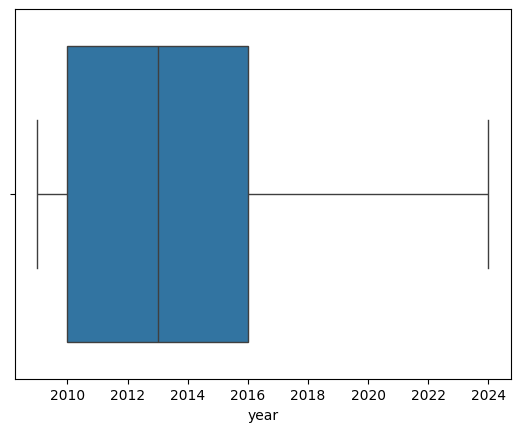

In [ ]:
sns.boxplot(data = df, x='year')
plt.show()

En algunos casos queremos cruzar esta información con datos categóricos:

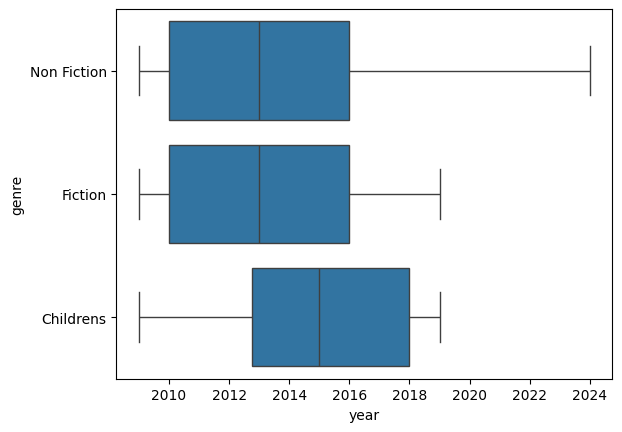

In [ ]:
sns.boxplot(data = df, x='year', y='genre')
plt.show()

Así podemos tener idea de como se distribuyen le fecha de publicación por género.

Para ver sus estadísticos el mejor método es las tablas cruzadas:

In [ ]:
df[['genre', 'rating', 'year']].groupby('genre').mean()

,rating,year
genre,,
Childrens,4.780000,2015.075000
Fiction,4.570229,2013.022901
Non Fiction,4.600000,2013.572222


Las opciones más usadas para las funciones de agregación son:
- Sum: `.sum()`
- Count: `.count()`
- Minimum: `.min()`
- Maximum: `.max()`
- Variance: `.var()`
- Standard deviation: `.std()`

Para usar las funciones de agregación usamos `.agg()`

In [ ]:
df[['rating', 'year']].agg(['mean', 'std'])

,rating,year
mean,4.609402,2013.538462
std,0.227150,3.327475


La ventaja de este truco es que se puede especificar por columna:

In [ ]:
df.agg({'rating': ['mean', 'std'], 'year': ['median']})

,rating,year
mean,4.609402,NaN
std,0.227150,NaN
median,NaN,2013.0


O creando una columna summary:

In [ ]:
df.groupby('genre').agg({'rating': ['mean', 'std'], 'year': ['median']})

rating              year
                 mean       std  median
genre                                  
Childrens    4.780000  0.122370  2015.0
Fiction      4.570229  0.281123  2013.0
Non Fiction  4.600000  0.180316  2013.0

Visto gráficamente:

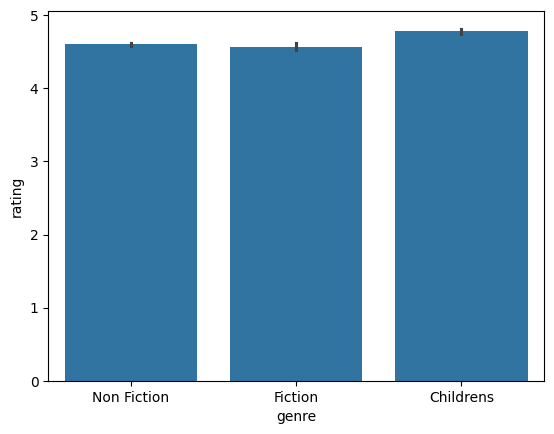

In [ ]:
sns.barplot(data = df, x='genre', y='rating')
plt.show()

Otra forma muy común es usando transformaciones como las *lambda functions*:

In [ ]:
df.groupby('genre')['rating'].apply(lambda x: x.std())

,rating
genre,
Childrens,0.122370
Fiction,0.281123
Non Fiction,0.180316


La ventaja de esta forma es que se puede usar para agregar como columna a un dataframe cambiando apply por transform, veamos:


In [ ]:
df['std_dev'] = df.groupby('genre')['rating'].transform(lambda x: x.std())
df.head()

,name,author,rating,year,genre,std_dev
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,2016,Non Fiction,0.180316
1,11/22/63: A Novel,Stephen King,4.6,2011,Fiction,0.281123
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,2018,Non Fiction,0.180316
3,1984 (Signet Classics),George Orwell,4.7,2017,Fiction,0.281123
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,2019,Childrens,0.122370


In [ ]:
df[['genre', 'std_dev']].value_counts()

,,count
genre,std_dev,
Non Fiction,0.180316,180
Fiction,0.281123,131
Childrens,0.122370,40


In [ ]:
df['median_year'] = df.groupby('year')['rating'].transform(lambda x: x.median())
df.head()

,name,author,rating,year,genre,std_dev,median_year
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,2016,Non Fiction,0.180316,4.7
1,11/22/63: A Novel,Stephen King,4.6,2011,Fiction,0.281123,4.6
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,2018,Non Fiction,0.180316,4.7
3,1984 (Signet Classics),George Orwell,4.7,2017,Fiction,0.281123,4.7
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,2019,Childrens,0.122370,4.8


In [ ]:
df[['year', 'median_year']].head()

,year,median_year
0,2016,4.7
1,2011,4.6
2,2018,4.7
3,2017,4.7
4,2019,4.8


### Outliers

Observemos la columna *rating*

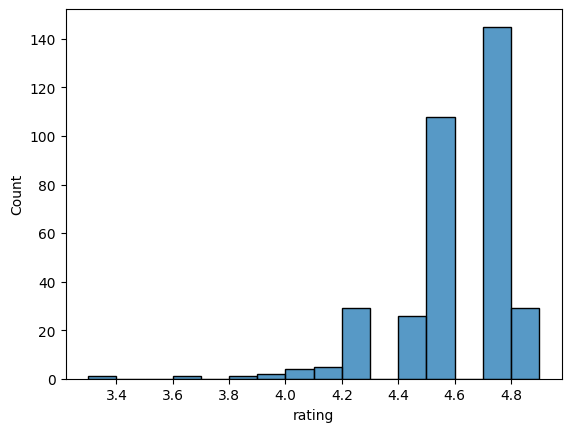

In [ ]:
sns.histplot(data = df, x='rating', binwidth=.1)
#también es válido sns.histplot(df['rating'])
plt.show()

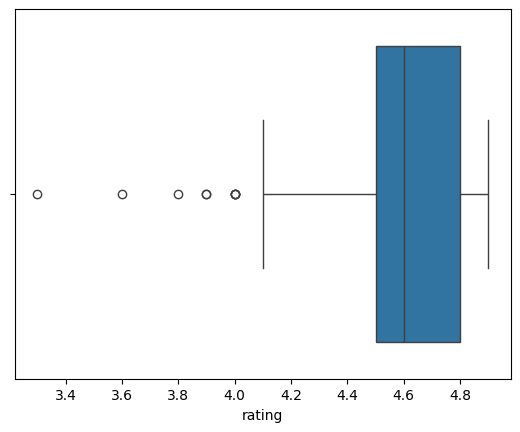

In [ ]:
sns.boxplot(data=df, x='rating')
plt.show()

In [ ]:
df.rating.describe()

,rating
count,351.000000
mean,4.609402
std,0.227150
min,3.300000
25%,4.500000
50%,4.600000
75%,4.800000
max,4.900000


Usando describe podemos identificar varias medidas de posición. Otra forma es:

In [ ]:
# 25th percentile
q1 = df['rating'].quantile(0.25)
# 50th percentile - Median
q2 = df['rating'].quantile(0.50)
# 75th percentile
q3 = df['rating'].quantile(0.75)
# IQR
iqr = q3 - q1

print(f"Q1 (25th percentile): {q1}")
print(f"Q2 (50th percentile - Median): {q2}")
print(f"Q3 (75th percentile): {q3}")
print(f"IQR (Interquartile Range): {iqr}")

Q1 (25th percentile): 4.5
Q2 (50th percentile - Median): 4.6
Q3 (75th percentile): 4.8
IQR (Interquartile Range): 0.2999999999999998


In [ ]:
#Upper threshold
upper = q3 + 1.5 * iqr

#Lower threshold
lower = q1 - 1.5 * iqr

print(upper, lower)

5.25 4.050000000000001


Vamos a filtrar con estos valores:

In [ ]:
df[(df['rating']<lower) | (df['rating']>upper)].head()

,name,author,rating,year,genre,std_dev,median_year
20,Allegiant,Veronica Roth,3.9,2013,Fiction,0.281123,4.60
87,Fifty Shades of Grey: Book One of the Fifty Sh...,E L James,3.8,2012,Fiction,0.281123,4.55
101,Go Set a Watchman: A Novel,Harper Lee,3.6,2015,Fiction,0.281123,4.70
104,Gone Girl,Gillian Flynn,4.0,2012,Fiction,0.281123,4.55
115,"Harry Potter and the Cursed Child, Parts 1 & 2...",J.K. Rowling,4.0,2016,Fiction,0.281123,4.70


¿Por qué buscar valores atípicos?
- Los valores atípicos son valores extremos.
- Podrían no representar con precisión nuestros datos.
- Pueden cambiar la media y la desviación estándar.
- Las pruebas estadísticas y los modelos de aprendizaje automático requieren datos con una distribución normal.

Veamos como quitarlos en este caso (es sólo por caracter explicativo)

In [ ]:
no_outliers.describe()

,rating,year,std_dev,median_year
count,342.000000,342.000000,342.000000,342.000000
mean,4.629825,2013.570175,0.209794,4.645760
std,0.187871,3.346034,0.056461,0.069273
min,4.100000,2009.000000,0.122370,4.550000
25%,4.500000,2010.000000,0.180316,4.600000
50%,4.700000,2013.000000,0.180316,4.600000
75%,4.800000,2016.000000,0.281123,4.700000
max,4.900000,2024.000000,0.281123,4.900000


In [ ]:
no_outliers= df[(df['rating']>lower) & (df['rating']<upper)]

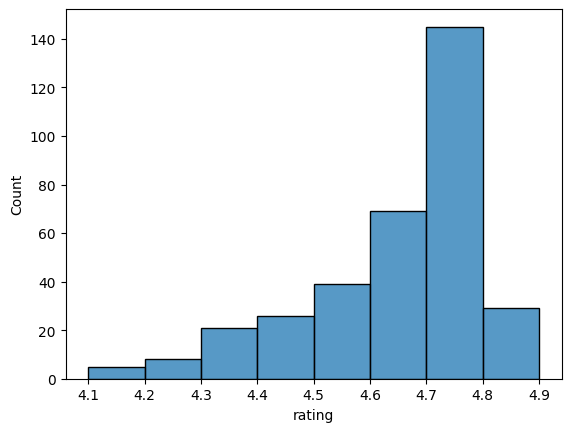

In [ ]:
sns.histplot(data = no_outliers, x='rating', binwidth=.1)
plt.show()

In [ ]:
no_outliers.describe()

,rating,year,std_dev,median_year
count,342.000000,342.000000,342.000000,342.000000
mean,4.629825,2013.570175,0.209794,4.645760
std,0.187871,3.346034,0.056461,0.069273
min,4.100000,2009.000000,0.122370,4.550000
25%,4.500000,2010.000000,0.180316,4.600000
50%,4.700000,2013.000000,0.180316,4.600000
75%,4.800000,2016.000000,0.281123,4.700000
max,4.900000,2024.000000,0.281123,4.900000


## Análisis Bidimensional

Para comenzar, es interesante ver la correlación:

- Describe la dirección y la fuerza de la relación entre dos variables.
- Establezca `numeric_only=True` para evitar errores con columnas no numéricas.

In [ ]:
df.corr(numeric_only=True) # en este ejemplo se esta usando la de pearson

,rating,year,std_dev,median_year
rating,1.000000,0.228028,-0.202245,0.257502
year,0.228028,1.000000,-0.156858,0.850101
std_dev,-0.202245,-0.156858,1.000000,-0.200381
median_year,0.257502,0.850101,-0.200381,1.000000


Se puede hacer con heatmaps:

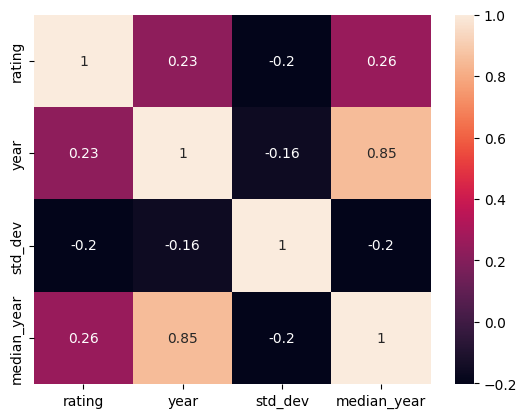

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

Puede que 2 variables estén correlacionadas, pero dicha correlación no sea lineal, para estos casos siempre es bueno analizar el scatterplot:

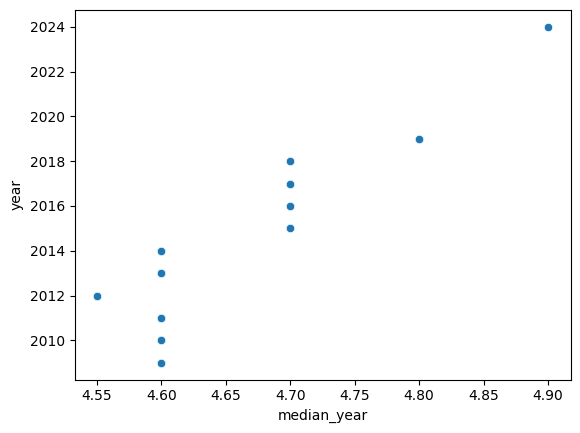

In [ ]:
sns.scatterplot(data=df, x="median_year", y="year")
plt.show()

Pero para observarlos todos, es ideal los pairplots:

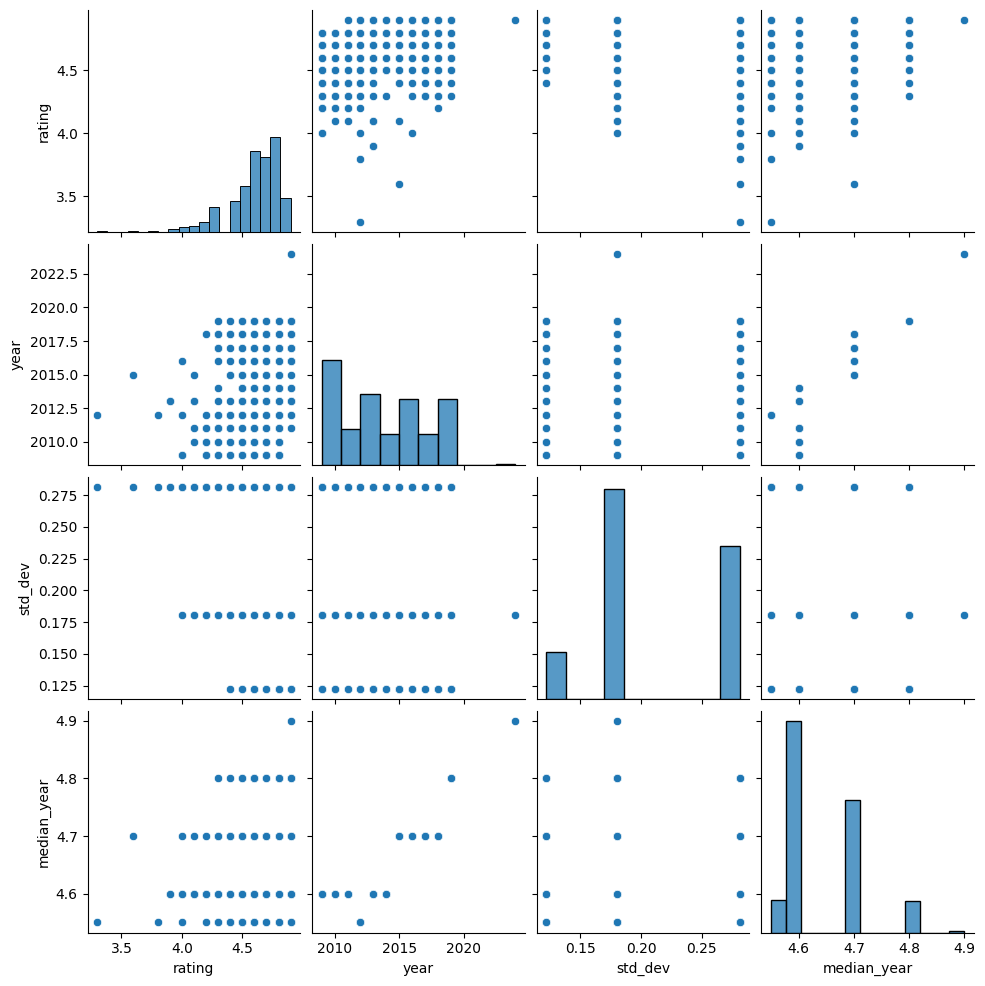

In [ ]:
sns.pairplot(data=df)
plt.show()